# Bootstrap Analysis for Self-Prioritization Effect (v4.1)

**Updates in v4.1**:
1. Unified legend style: Legend below title as subtitle (Style 2)
2. Three versions of sample size:
   - **Max**: No limit, use maximum available sample size for each condition
   - **Original**: As calculated (may differ between Shape and Label)
   - **Aligned**: Limited to min(Shape, Label) for fair comparison

**Output**: 3 combined figures (2x2 layout each)

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set APA style
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
# Define paths and load data
data_path = Path("D:/GitHub_programe/GitHub/SPE_Database/1_Data")
output_path = Path("D:/GitHub_programe/GitHub/SPE_Database/3_Reports/Bootstrap/v4_legend_optimized")
output_path.mkdir(exist_ok=True)

# Load all Clean.csv files
clean_files = list(data_path.rglob("*_Clean.csv"))
print(f"Found {len(clean_files)} Clean.csv files")

all_data = []
for file_path in clean_files:
    try:
        df = pd.read_csv(file_path)
        df['Source'] = file_path.stem
        all_data.append(df)
    except Exception as e:
        print(f"Error loading {file_path.name}: {e}")

merged_df = pd.concat(all_data, ignore_index=True)
print(f"Total merged data: {len(merged_df)} rows")

Found 72 Clean.csv files
Total merged data: 1591899 rows


In [4]:
# Prepare data
has_label = 'Label_Standardized_Identity' in merged_df.columns
if not has_label:
    print("WARNING: Label_Standardized_Identity not found. Using Shape for both.")
    merged_df['Label_Standardized_Identity'] = merged_df['Shape_Standardized_Identity']

mismatch_df = merged_df[merged_df['Matching'] == 'Nonmatching'].copy()
print(f"Mismatch trials: {len(mismatch_df)} rows")
print(f"Unique participants: {mismatch_df['Subject'].nunique()}")

Mismatch trials: 853015 rows
Unique participants: 1676


In [5]:
# Define helper functions
def cohens_d(group1, group2):
    """Calculate Cohen's d between two groups."""
    n1, n2 = len(group1), len(group2)
    if n1 < 2 or n2 < 2:
        return np.nan
    mean1, mean2 = np.mean(group1), np.mean(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_sd = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (mean1 - mean2) / pooled_sd if pooled_sd != 0 else np.nan

def filter_valid_subjects(df, identity_column):
    """Filter subjects with Self, Stranger, and at least 3 identities."""
    valid_subjects = []
    for subject, subj_df in df.groupby('Subject'):
        identities = set(subj_df[identity_column].dropna().unique())
        if 'Self' in identities and 'Stranger' in identities and len(identities) >= 3:
            valid_subjects.append(subject)
    return valid_subjects

print("Helper functions defined!")

Helper functions defined!


In [6]:
# Define data processing functions
def process_data_strict(df, analysis_type='Shape'):
    """Process data with STRICT filtering."""
    if analysis_type == 'Shape':
        identity_column = 'Shape_Standardized_Identity'
        secondary_column = 'Label_Standardized_Identity'
    else:
        identity_column = 'Label_Standardized_Identity'
        secondary_column = 'Shape_Standardized_Identity'
    
    valid_subjects = filter_valid_subjects(df, identity_column)
    df_filtered = df[df['Subject'].isin(valid_subjects)].copy()
    
    df_filtered['Primary'] = df_filtered[identity_column].apply(
        lambda x: x if x in ['Self', 'Stranger'] else 'Other'
    )
    df_filtered['Secondary'] = df_filtered[secondary_column].apply(
        lambda x: x if x in ['Self', 'Stranger'] else 'Other'
    )
    
    mask = (
        (df_filtered['Primary'] == 'Self') |
        ((df_filtered['Primary'] == 'Stranger') & (df_filtered['Secondary'] != 'Self')) |
        (df_filtered['Primary'] == 'Other')
    )
    return df_filtered[mask].copy()

def process_data_loose(df, analysis_type='Shape'):
    """Process data with LOOSE filtering."""
    identity_column = 'Shape_Standardized_Identity' if analysis_type == 'Shape' else 'Label_Standardized_Identity'
    df_filtered = df.copy()
    df_filtered['Primary'] = df_filtered[identity_column].apply(
        lambda x: x if x in ['Self', 'Stranger'] else 'Other'
    )
    return df_filtered[df_filtered['Primary'].isin(['Self', 'Stranger'])].copy()

print("Data processing functions defined!")

Data processing functions defined!


In [7]:
# Define analysis and bootstrap functions
def calculate_cohens_d_per_subject(df, measure='RT', min_trials=2):
    """Calculate Cohen's d for each participant."""
    results = []
    for subject, subj_df in df.groupby('Subject'):
        self_data = subj_df[subj_df['Primary'] == 'Self']
        stranger_data = subj_df[subj_df['Primary'] == 'Stranger']
        
        if measure == 'RT':
            self_values = self_data[self_data['ACC'] == 1]['RT_ms'].dropna().values
            stranger_values = stranger_data[stranger_data['ACC'] == 1]['RT_ms'].dropna().values
        else:
            self_values = self_data['ACC'].dropna().values
            stranger_values = stranger_data['ACC'].dropna().values
        
        if len(self_values) < min_trials or len(stranger_values) < min_trials:
            continue
        
        d = cohens_d(stranger_values, self_values) if measure == 'RT' else cohens_d(self_values, stranger_values)
        if not np.isnan(d):
            results.append({'Subject': subject, 'Cohens_d': d})
    return pd.DataFrame(results)

def bootstrap_analysis(cohens_d_values, n_bootstrap=500, min_n=10, step=10, max_n=None):
    """Perform bootstrap resampling WITH REPLACEMENT."""
    total_n = len(cohens_d_values)
    if total_n < min_n:
        return pd.DataFrame()
    
    # If max_n is None, use total_n (no limit)
    if max_n is None:
        max_n = total_n
    else:
        max_n = min(max_n, total_n)
    
    sample_sizes = list(range(min_n, max_n + 1, step))
    if max_n % step != 0 and max_n not in sample_sizes:
        sample_sizes.append(max_n)
    sample_sizes = sorted(set(sample_sizes))
    
    results = []
    for n in sample_sizes:
        if n > total_n:
            continue
        bootstrap_means = [np.mean(np.random.choice(cohens_d_values, size=n, replace=True)) for _ in range(n_bootstrap)]
        results.append({
            'SampleSize': n,
            'Mean_d': np.mean(bootstrap_means),
            'CI_lower': np.percentile(bootstrap_means, 2.5),
            'CI_upper': np.percentile(bootstrap_means, 97.5)
        })
    return pd.DataFrame(results)

print("Analysis functions defined!")

Analysis functions defined!


In [8]:
# Run complete analysis
def run_analysis(data_filtered, filtering_type='Strict', n_bootstrap=500):
    """Run complete analysis for RT and ACC with Shape and Label."""
    results = {}
    
    print(f"\n=== {filtering_type} Filtering ===")
    
    # RT Analysis
    data_rt = data_filtered[data_filtered['Matching'] == 'Nonmatching'].copy()
    if filtering_type == 'Strict':
        rt_shape_data = process_data_strict(data_rt, 'Shape')
        rt_label_data = process_data_strict(data_rt, 'Label')
    else:
        rt_shape_data = process_data_loose(data_rt, 'Shape')
        rt_label_data = process_data_loose(data_rt, 'Label')
    
    rt_shape_cohens = calculate_cohens_d_per_subject(rt_shape_data, 'RT')
    rt_label_cohens = calculate_cohens_d_per_subject(rt_label_data, 'RT')
    print(f"RT - Shape: {len(rt_shape_cohens)}, Label: {len(rt_label_cohens)}")
    
    # Calculate max_n for aligned version
    rt_max_n = min(len(rt_shape_cohens), len(rt_label_cohens))
    
    # Bootstrap: Max version (no limit)
    rt_shape_boot_max = bootstrap_analysis(rt_shape_cohens['Cohens_d'].values, n_bootstrap) if len(rt_shape_cohens) > 0 else pd.DataFrame()
    rt_label_boot_max = bootstrap_analysis(rt_label_cohens['Cohens_d'].values, n_bootstrap) if len(rt_label_cohens) > 0 else pd.DataFrame()
    
    # Bootstrap: Aligned version (limited to min)
    rt_shape_boot_aligned = bootstrap_analysis(rt_shape_cohens['Cohens_d'].values, n_bootstrap, max_n=rt_max_n) if len(rt_shape_cohens) > 0 else pd.DataFrame()
    rt_label_boot_aligned = bootstrap_analysis(rt_label_cohens['Cohens_d'].values, n_bootstrap, max_n=rt_max_n) if len(rt_label_cohens) > 0 else pd.DataFrame()
    
    # Add Identity column
    for df in [rt_shape_boot_max, rt_label_boot_max, rt_shape_boot_aligned, rt_label_boot_aligned]:
        if not df.empty:
            df['Identity'] = 'Shape' if df is rt_shape_boot_max or df is rt_shape_boot_aligned else 'Label'
    
    # ACC Analysis
    if filtering_type == 'Strict':
        acc_shape_data = process_data_strict(data_filtered, 'Shape')
        acc_label_data = process_data_strict(data_filtered, 'Label')
    else:
        acc_shape_data = process_data_loose(data_filtered, 'Shape')
        acc_label_data = process_data_loose(data_filtered, 'Label')
    
    acc_shape_cohens = calculate_cohens_d_per_subject(acc_shape_data, 'ACC')
    acc_label_cohens = calculate_cohens_d_per_subject(acc_label_data, 'ACC')
    print(f"ACC - Shape: {len(acc_shape_cohens)}, Label: {len(acc_label_cohens)}")
    
    acc_max_n = min(len(acc_shape_cohens), len(acc_label_cohens))
    
    # Bootstrap: Max version
    acc_shape_boot_max = bootstrap_analysis(acc_shape_cohens['Cohens_d'].values, n_bootstrap) if len(acc_shape_cohens) > 0 else pd.DataFrame()
    acc_label_boot_max = bootstrap_analysis(acc_label_cohens['Cohens_d'].values, n_bootstrap) if len(acc_label_cohens) > 0 else pd.DataFrame()
    
    # Bootstrap: Aligned version
    acc_shape_boot_aligned = bootstrap_analysis(acc_shape_cohens['Cohens_d'].values, n_bootstrap, max_n=acc_max_n) if len(acc_shape_cohens) > 0 else pd.DataFrame()
    acc_label_boot_aligned = bootstrap_analysis(acc_label_cohens['Cohens_d'].values, n_bootstrap, max_n=acc_max_n) if len(acc_label_cohens) > 0 else pd.DataFrame()
    
    for df in [acc_shape_boot_max, acc_label_boot_max, acc_shape_boot_aligned, acc_label_boot_aligned]:
        if not df.empty:
            df['Identity'] = 'Shape' if df is acc_shape_boot_max or df is acc_shape_boot_aligned else 'Label'
    
    return {
        'rt_bootstrap_max': pd.concat([rt_shape_boot_max, rt_label_boot_max], ignore_index=True),
        'rt_bootstrap_aligned': pd.concat([rt_shape_boot_aligned, rt_label_boot_aligned], ignore_index=True),
        'acc_bootstrap_max': pd.concat([acc_shape_boot_max, acc_label_boot_max], ignore_index=True),
        'acc_bootstrap_aligned': pd.concat([acc_shape_boot_aligned, acc_label_boot_aligned], ignore_index=True)
    }

# Run analyses
print("=" * 80)
print("STRICT FILTERING")
print("=" * 80)
strict_results = run_analysis(mismatch_df, 'Strict', 500)

print("\n" + "=" * 80)
print("LOOSE FILTERING")
print("=" * 80)
loose_results = run_analysis(mismatch_df, 'Loose', 500)

STRICT FILTERING

=== Strict Filtering ===
RT - Shape: 792, Label: 610
ACC - Shape: 782, Label: 590

LOOSE FILTERING

=== Loose Filtering ===
RT - Shape: 964, Label: 813
ACC - Shape: 954, Label: 800


In [9]:
# Create figure function - Style 2: Legend below title as subtitle
def create_figure_style2(strict_rt, strict_acc, loose_rt, loose_acc, version='max'):
    """
    Create APA-style figure with legend below title as subtitle.
    
    Parameters:
    - strict_rt, strict_acc: DataFrames for strict filtering
    - loose_rt, loose_acc: DataFrames for loose filtering
    - version: 'max', 'aligned' - determines filename
    """
    shape_color = '#2E86AB'
    label_color = '#A23B72'
    
    # Fixed axis limits for consistency
    x_min, x_max = 0, 550  # Slightly larger to accommodate max version
    y_min, y_max = -0.4, 0.4
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    plot_configs = [
        (axes[0, 0], strict_rt, 'RT', 'Strict'),
        (axes[0, 1], strict_acc, 'ACC', 'Strict'),
        (axes[1, 0], loose_rt, 'RT', 'Loose'),
        (axes[1, 1], loose_acc, 'ACC', 'Loose'),
    ]
    
    for ax, data, measure, filtering in plot_configs:
        # APA style
        ax.set_facecolor('white')
        ax.grid(False)
        
        if data.empty:
            ax.text(0.5, 0.5, 'No Data', ha='center', va='center', 
                   transform=ax.transAxes, fontsize=14)
            continue
        
        # Plot data for Shape and Label
        for identity in ['Shape', 'Label']:
            subset = data[data['Identity'] == identity]
            if subset.empty:
                continue
            
            color = shape_color if identity == 'Shape' else label_color
            ax.plot(subset['SampleSize'], subset['Mean_d'], 
                   color=color, linewidth=2, label=identity)
            ax.fill_between(subset['SampleSize'], 
                           subset['CI_lower'], 
                           subset['CI_upper'], 
                           color=color, alpha=0.2)
            ax.scatter(subset['SampleSize'], subset['Mean_d'], 
                      color=color, s=20, zorder=5)
        
        # Zero reference line
        ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
        
        # Fixed axes
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        
        # Labels
        y_label = "Cohen's d (Stranger - Self)" if measure == 'RT' else "Cohen's d (Self - Stranger)"
        subplot_label = ('A' if filtering == 'Strict' else 'C') if measure == 'RT' else ('B' if filtering == 'Strict' else 'D')
        
        ax.set_xlabel('Sample Size', fontsize=12, fontweight='bold')
        ax.set_ylabel(y_label, fontsize=12, fontweight='bold')
        
        # Main title
        title_text = f"SPE calculated by {filtering.lower()} approach"
        ax.set_title(title_text, fontsize=13, fontweight='bold', 
                    family='Times New Roman', pad=20)
        
        # Subtitle with measure and legend
        # Position legend as subtitle below main title
        ax.text(0.5, 1.02, f'({measure})', transform=ax.transAxes, 
               fontsize=10, ha='right', va='bottom', color='black')
        ax.text(0.52, 1.02, ' ■', transform=ax.transAxes, 
               fontsize=12, ha='left', va='bottom', color=shape_color, fontweight='bold')
        ax.text(0.58, 1.02, ' Shape  ', transform=ax.transAxes, 
               fontsize=10, ha='left', va='bottom', color='black')
        ax.text(0.70, 1.02, '■', transform=ax.transAxes, 
               fontsize=12, ha='left', va='bottom', color=label_color, fontweight='bold')
        ax.text(0.73, 1.02, ' Label', transform=ax.transAxes, 
               fontsize=10, ha='left', va='bottom', color='black')
        
        # Subplot label (A, B, C, D)
        ax.text(-0.08, 1.15, subplot_label, transform=ax.transAxes, 
               fontsize=16, fontweight='bold', va='top', ha='right')
        
        # APA style: remove top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(1)
        ax.spines['bottom'].set_linewidth(1)
        ax.tick_params(axis='both', which='major', labelsize=10)
    
    plt.tight_layout()
    
    # Save figure
    filename = f'combined_figures_style2_{version}.png'
    plt.savefig(output_path / filename, dpi=300, bbox_inches='tight', 
               facecolor='white', edgecolor='none')
    plt.show()
    print(f"Saved: {filename}")
    
    return fig

print("Figure function defined!")

Figure function defined!



VERSION 1: MAX SAMPLE SIZE (NO LIMIT)
Each condition uses its maximum available sample size


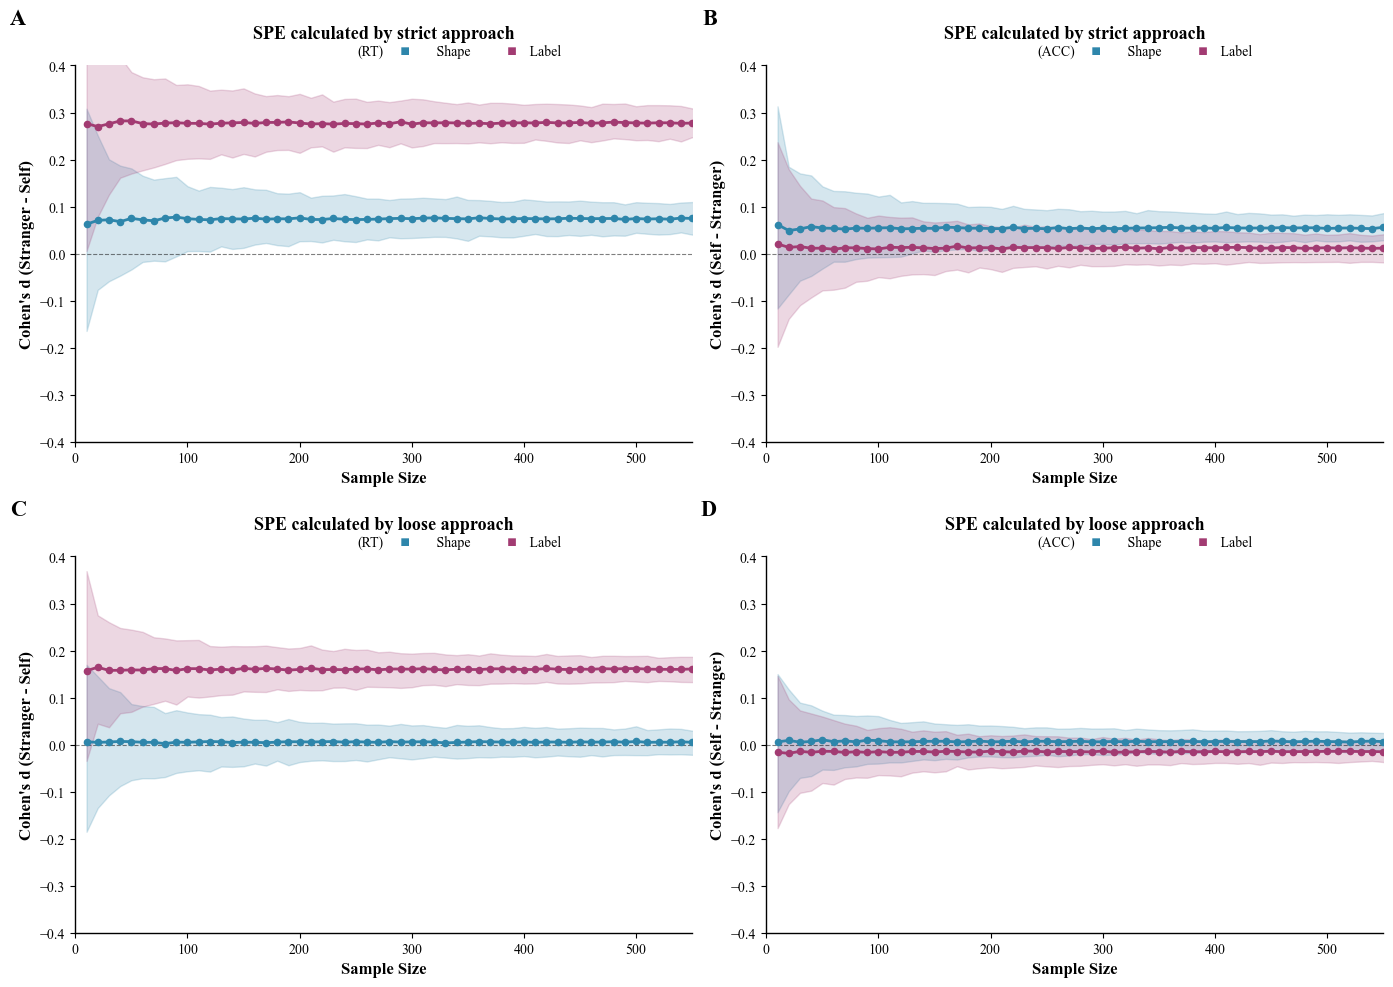

Saved: combined_figures_style2_max.png


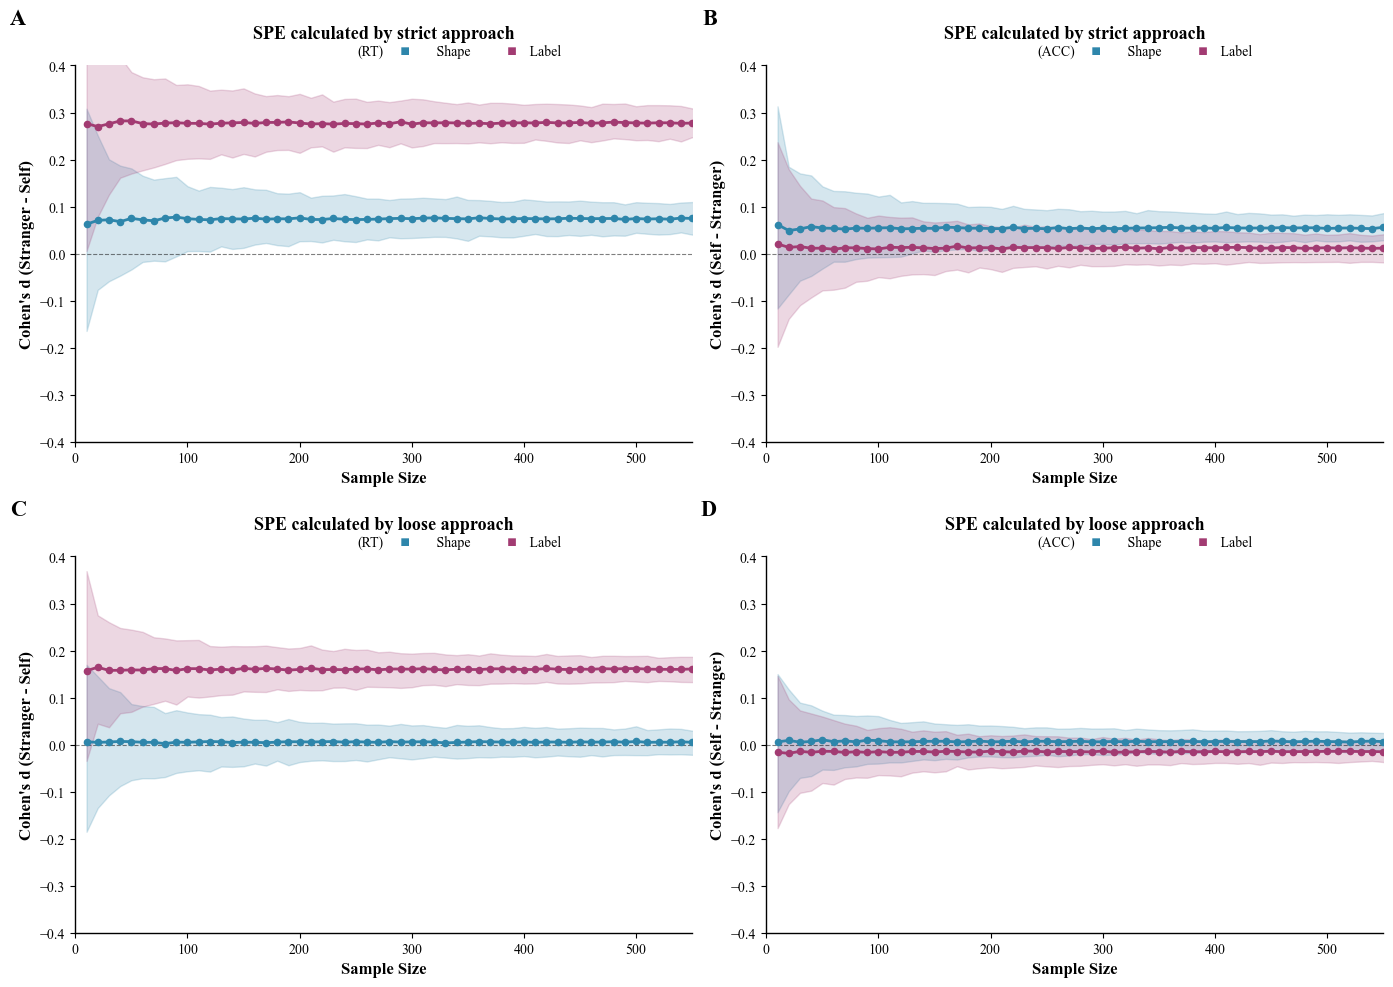

In [10]:
# Generate Version 1: Max sample size (no limit)
print("\n" + "=" * 80)
print("VERSION 1: MAX SAMPLE SIZE (NO LIMIT)")
print("=" * 80)
print("Each condition uses its maximum available sample size")

create_figure_style2(
    strict_results['rt_bootstrap_max'],
    strict_results['acc_bootstrap_max'],
    loose_results['rt_bootstrap_max'],
    loose_results['acc_bootstrap_max'],
    version='max'
)


VERSION 2: ALIGNED SAMPLE SIZE (MIN OF SHAPE AND LABEL)
Both Shape and Label use the same maximum sample size


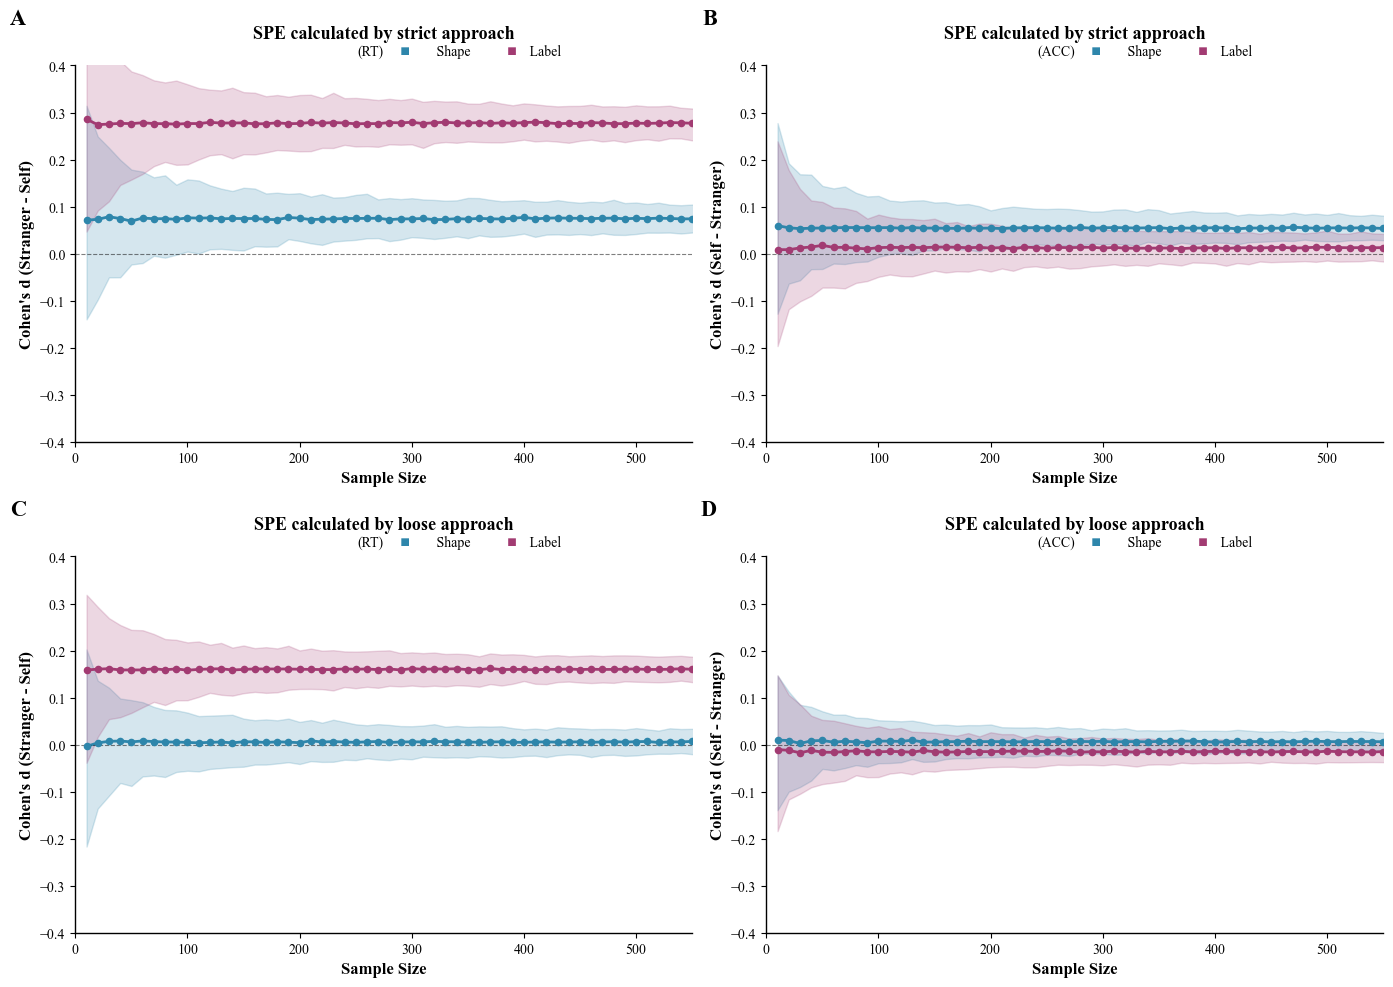

Saved: combined_figures_style2_aligned.png


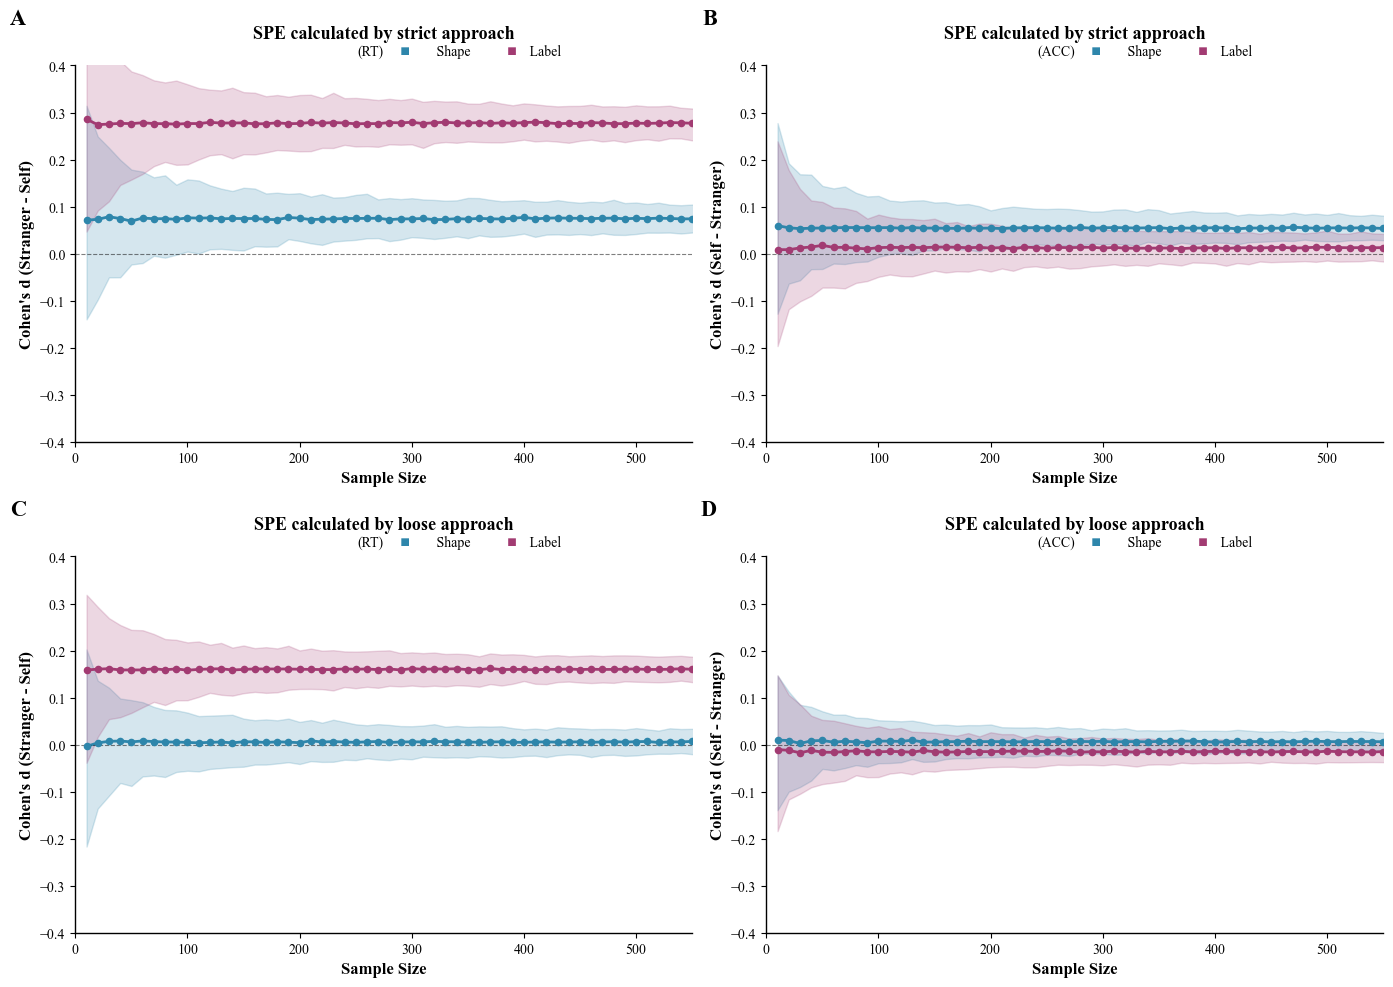

In [11]:
# Generate Version 2: Aligned sample size (min of Shape and Label)
print("\n" + "=" * 80)
print("VERSION 2: ALIGNED SAMPLE SIZE (MIN OF SHAPE AND LABEL)")
print("=" * 80)
print("Both Shape and Label use the same maximum sample size")

create_figure_style2(
    strict_results['rt_bootstrap_aligned'],
    strict_results['acc_bootstrap_aligned'],
    loose_results['rt_bootstrap_aligned'],
    loose_results['acc_bootstrap_aligned'],
    version='aligned'
)

In [12]:
# Save all results to CSV
print("\n" + "=" * 80)
print("SAVING RESULTS")
print("=" * 80)

# Save bootstrap results
strict_results['rt_bootstrap_max'].to_csv(output_path / 'bootstrap_rt_strict_max.csv', index=False)
strict_results['acc_bootstrap_max'].to_csv(output_path / 'bootstrap_acc_strict_max.csv', index=False)
loose_results['rt_bootstrap_max'].to_csv(output_path / 'bootstrap_rt_loose_max.csv', index=False)
loose_results['acc_bootstrap_max'].to_csv(output_path / 'bootstrap_acc_loose_max.csv', index=False)

strict_results['rt_bootstrap_aligned'].to_csv(output_path / 'bootstrap_rt_strict_aligned.csv', index=False)
strict_results['acc_bootstrap_aligned'].to_csv(output_path / 'bootstrap_acc_strict_aligned.csv', index=False)
loose_results['rt_bootstrap_aligned'].to_csv(output_path / 'bootstrap_rt_loose_aligned.csv', index=False)
loose_results['acc_bootstrap_aligned'].to_csv(output_path / 'bootstrap_acc_loose_aligned.csv', index=False)

print("\nData files saved:")
print("  - bootstrap_rt_strict_max.csv")
print("  - bootstrap_acc_strict_max.csv")
print("  - bootstrap_rt_loose_max.csv")
print("  - bootstrap_acc_loose_max.csv")
print("  - bootstrap_rt_strict_aligned.csv")
print("  - bootstrap_acc_strict_aligned.csv")
print("  - bootstrap_rt_loose_aligned.csv")
print("  - bootstrap_acc_loose_aligned.csv")


SAVING RESULTS

Data files saved:
  - bootstrap_rt_strict_max.csv
  - bootstrap_acc_strict_max.csv
  - bootstrap_rt_loose_max.csv
  - bootstrap_acc_loose_max.csv
  - bootstrap_rt_strict_aligned.csv
  - bootstrap_acc_strict_aligned.csv
  - bootstrap_rt_loose_aligned.csv
  - bootstrap_acc_loose_aligned.csv


In [14]:
# Print summary statistics
print("\n" + "=" * 80)
print("ANALYSIS SUMMARY")
print("=" * 80)

# Print Strict Filtering results
for version_name, rt_data, acc_data in [
    ('Max', strict_results['rt_bootstrap_max'], strict_results['acc_bootstrap_max']),
    ('Aligned', strict_results['rt_bootstrap_aligned'], strict_results['acc_bootstrap_aligned'])
]:
    print(f"\nStrict Filtering - {version_name} Version:")
    for measure, data in [('RT', rt_data), ('ACC', acc_data)]:
        if not data.empty:
            print(f"  {measure}:")
            for identity in ['Shape', 'Label']:
                subset = data[data['Identity'] == identity]
                if not subset.empty:
                    max_n = subset['SampleSize'].max()
                    final = subset[subset['SampleSize'] == max_n].iloc[0]
                    sig = "Yes" if (final['CI_lower'] > 0 or final['CI_upper'] < 0) else "No"
                    print(f"    {identity}: Max N = {max_n}, Mean d = {final['Mean_d']:.3f}, "
                          f"95% CI [{final['CI_lower']:.3f}, {final['CI_upper']:.3f}], Sig: {sig}")

# Print Loose Filtering results
for version_name, rt_data, acc_data in [
    ('Max', loose_results['rt_bootstrap_max'], loose_results['acc_bootstrap_max']),
    ('Aligned', loose_results['rt_bootstrap_aligned'], loose_results['acc_bootstrap_aligned'])
]:
    print(f"\nLoose Filtering - {version_name} Version:")
    for measure, data in [('RT', rt_data), ('ACC', acc_data)]:
        if not data.empty:
            print(f"  {measure}:")
            for identity in ['Shape', 'Label']:
                subset = data[data['Identity'] == identity]
                if not subset.empty:
                    max_n = subset['SampleSize'].max()
                    final = subset[subset['SampleSize'] == max_n].iloc[0]
                    sig = "Yes" if (final['CI_lower'] > 0 or final['CI_upper'] < 0) else "No"
                    print(f"    {identity}: Max N = {max_n}, Mean d = {final['Mean_d']:.3f}, "
                          f"95% CI [{final['CI_lower']:.3f}, {final['CI_upper']:.3f}], Sig: {sig}")

print("\n" + "=" * 80)
print("OUTPUT FILES")
print("=" * 80)
print("\nFigures (300 dpi):")
print("  - combined_figures_style2_max.png (No sample size limit)")
print("  - combined_figures_style2_aligned.png (Aligned to min of Shape/Label)")
print("\nRecommendation:")
print("  - Use 'max' version to see full range of data")
print("  - Use 'aligned' version for fair comparison between Shape and Label")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)


ANALYSIS SUMMARY

Strict Filtering - Max Version:
  RT:
    Shape: Max N = 792, Mean d = 0.074, 95% CI [0.049, 0.100], Sig: Yes
    Label: Max N = 610, Mean d = 0.278, 95% CI [0.246, 0.313], Sig: Yes
  ACC:
    Shape: Max N = 782, Mean d = 0.053, 95% CI [0.032, 0.077], Sig: Yes
    Label: Max N = 590, Mean d = 0.012, 95% CI [-0.013, 0.040], Sig: No

Strict Filtering - Aligned Version:
  RT:
    Shape: Max N = 610, Mean d = 0.075, 95% CI [0.045, 0.103], Sig: Yes
    Label: Max N = 610, Mean d = 0.277, 95% CI [0.245, 0.310], Sig: Yes
  ACC:
    Shape: Max N = 590, Mean d = 0.054, 95% CI [0.028, 0.080], Sig: Yes
    Label: Max N = 590, Mean d = 0.013, 95% CI [-0.017, 0.037], Sig: No

Loose Filtering - Max Version:
  RT:
    Shape: Max N = 964, Mean d = 0.005, 95% CI [-0.014, 0.024], Sig: No
    Label: Max N = 813, Mean d = 0.160, 95% CI [0.140, 0.181], Sig: Yes
  ACC:
    Shape: Max N = 954, Mean d = 0.007, 95% CI [-0.007, 0.021], Sig: No
    Label: Max N = 800, Mean d = -0.015, 95% CI [

## Summary of v4.1

### Legend Style
All figures use **Style 2**: Legend below title as subtitle

```
SPE calculated by strict approach
(RT)  ■ Shape  ■ Label
```

### Sample Size Versions

1. **Max Version** (`combined_figures_style2_max.png`)
   - No sample size limit
   - Shape and Label may have different endpoints
   - Shows full range of available data

2. **Aligned Version** (`combined_figures_style2_aligned.png`)
   - Limited to min(Shape, Label) sample size
   - Both lines end at same point
   - Allows fair comparison

### Recommendations

| Purpose | Recommended Figure |
|---------|-------------------|
| Publication | `combined_figures_style2_aligned.png` |
| Exploratory analysis | `combined_figures_style2_max.png` |
| Presentation | `combined_figures_style2_aligned.png` |